**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = os.getcwd()

THETA = 2  # Frank dependence parameter (any real != 0)
GRID_STEP = 0.02

**Cell 2 — Grid on (0,1]^2**

In [2]:
u = np.arange(GRID_STEP, 1.00, GRID_STEP)
v = u
U, V = np.meshgrid(u, v)

**Cell 3 — Frank copula density function**

In [3]:
def frank_copula_density(U, V, theta):
    # c(u,v) = -theta*(exp(-theta(u+v+1)) - exp(-theta(u+v)))
    #           / (exp(-theta) + exp(-theta(u+v)) - exp(-theta*u) - exp(-theta*v))^2
    numer = -theta * (np.exp(-theta * (U + V + 1)) - np.exp(-theta * (U + V)))
    denom = (
        np.exp(-theta) + np.exp(-theta * (U + V)) - np.exp(-theta * U) - np.exp(-theta * V)
    ) ** 2
    return numer / denom

f = frank_copula_density(U, V, THETA)

**Cell 4 — 3D surface plot**

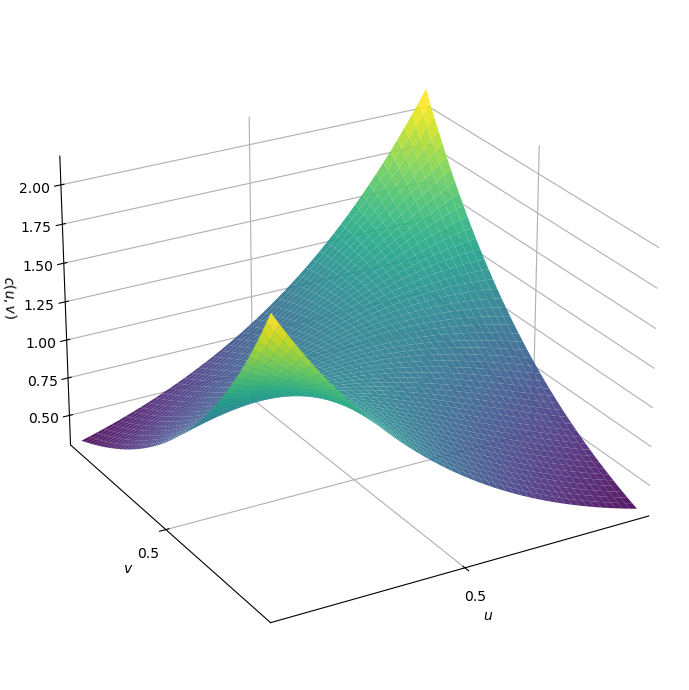

In [4]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(U, V, f, cmap="viridis", edgecolor="none", alpha=0.9)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("white")
ax.yaxis.pane.set_edgecolor("white")
ax.zaxis.pane.set_edgecolor("white")

ax.set_xlabel("$u$")
ax.set_ylabel("$v$")
ax.set_zlabel("$c(u,v)$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([0.5])
ax.set_yticks([0.5])
ax.view_init(elev=25, azim=240)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "frank_copula_density.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()